#### Bibliotecas

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix, accuracy_score, f1_score
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn import svm
from sklearn.svm import SVC

#### Dataset e pré-processamento

In [45]:
df = pd.read_csv('Complete_UPV_Database_raw.csv')
df

,Literature,Specimen ID,Country,Specimen Type,Specimen Age (days),Rebar Present,UPV Device Brand & Model,Transducer Diameter (mm),Transducer Frequency (kHz),Standard,...,Width/Diameter (mm),Max Aggregate Size (mm),W/C Ratio,Strength Class,"Design Strength, fck (MPa)","fc,core (MPa)","fc,ref (MPa)","fc,cyl (MPa)",Notes,Unnamed: 24
0,Cianfrone & Facaoaru (1979),C1_25a,Italy,Cube - Laboratory,1.0,False,NaN,NaN,50.0,BS 4408: Part 5 (1974),...,150.0,30.0,NaN,NaN,NaN,16.08,16.08,13.35,NaN,NaN
1,Cianfrone & Facaoaru (1979),C2_25b,Italy,Cube - Laboratory,2.0,False,NaN,NaN,50.0,BS 4408: Part 5 (1974),...,150.0,30.0,NaN,NaN,NaN,27.95,27.95,23.20,NaN,NaN
2,Cianfrone & Facaoaru (1979),C3_25c,Italy,Cube - Laboratory,7.0,False,NaN,NaN,50.0,BS 4408: Part 5 (1974),...,150.0,30.0,NaN,NaN,NaN,38.64,38.64,32.07,NaN,NaN
3,Cianfrone & Facaoaru (1979),C4_25d,Italy,Cube - Laboratory,28.0,False,NaN,NaN,50.0,BS 4408: Part 5 (1974),...,150.0,30.0,NaN,NaN,NaN,47.86,47.86,39.72,NaN,NaN
4,Cianfrone & Facaoaru (1979),C5_123,Italy,Cube - Laboratory,28.0,False,NaN,NaN,50.0,BS 4408: Part 5 (1974),...,150.0,30.0,NaN,NaN,NaN,56.19,56.19,46.64,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4886,Matthews et al. (2025),F11_41,Netherlands,Cylinder - In-situ,13880.0,False,PROCEQ PUNDIT PL200,50.0,54.0,EN 12504-4 (2004),...,94.0,14.0,NaN,B52.5,45.0,86.00,75.05,63.95,NaN,NaN
4887,Matthews et al. (2025),F11_42,Netherlands,Cylinder - In-situ,13880.0,False,PROCEQ PUNDIT PL200,50.0,54.0,EN 12504-4 (2004),...,94.0,13.0,NaN,B52.5,45.0,76.30,66.59,55.49,NaN,NaN
4888,Matthews et al. (2025),F10_43,Netherlands,Cylinder - In-situ,13880.0,False,PROCEQ PUNDIT PL200,50.0,54.0,EN 12504-4 (2004),...,92.0,10.0,NaN,B52.5,45.0,80.10,69.91,58.81,NaN,NaN
4889,Matthews et al. (2025),F10_44,Netherlands,Cylinder - In-situ,13880.0,False,PROCEQ PUNDIT PL200,50.0,54.0,EN 12504-4 (2004),...,95.0,11.0,NaN,B52.5,45.0,86.30,75.32,64.22,NaN,NaN


In [67]:
cols_to_drop = [
    'Literature', 'Specimen ID', 'UPV Device Brand & Model', 'Country', 
    'Standard', 'Strength Class', 'W/C Ratio', 'Design Strength, fck (MPa)', 
    'Notes', 'Unnamed: 24', 'fc,core (MPa)', 'fc,ref (MPa)', 
    'Transducer Diameter (mm)',
]

cols_to_dropna = [
    'Specimen Age (days)', 'Transducer Frequency (kHz)', 
    'Max Aggregate Size (mm)', 'Height (mm)', 'Width/Diameter (mm)', 
    'Rebar Present', 'Specimen Type', 'Compression Specimen', 'Test Type', 'fc,cyl (MPa)',
]

df_cleaned = df.drop(columns=cols_to_drop)
df_cleaned = df_cleaned.dropna(subset=cols_to_dropna)

mask_no_rebar = df_cleaned['Rebar Present'].astype(str).str.lower() != 'true'
df_cleaned = df_cleaned[mask_no_rebar]

df_cleaned = df_cleaned.drop(columns=['Rebar Present']).reset_index(drop=True)
df_cleaned

,Specimen Type,Specimen Age (days),Transducer Frequency (kHz),Test Type,No. Tests,"Average Velocity, Vp (m/s)",Compression Specimen,Height (mm),Width/Diameter (mm),Max Aggregate Size (mm),"fc,cyl (MPa)"
0,Cube - Laboratory,1.0,50.0,Direct,3.0,4440,Cube,150.0,150.0,30.0,13.35
1,Cube - Laboratory,2.0,50.0,Direct,3.0,4820,Cube,150.0,150.0,30.0,23.20
2,Cube - Laboratory,7.0,50.0,Direct,3.0,5130,Cube,150.0,150.0,30.0,32.07
3,Cube - Laboratory,28.0,50.0,Direct,3.0,5230,Cube,150.0,150.0,30.0,39.72
4,Cube - Laboratory,28.0,50.0,Direct,3.0,5050,Cube,150.0,150.0,30.0,46.64
...,...,...,...,...,...,...,...,...,...,...,...
1001,Cylinder - In-situ,13880.0,54.0,Direct,1.0,4990,Core,94.0,94.0,14.0,63.95
1002,Cylinder - In-situ,13880.0,54.0,Direct,1.0,4960,Core,94.0,94.0,13.0,55.49
1003,Cylinder - In-situ,13880.0,54.0,Direct,1.0,5090,Core,94.0,92.0,10.0,58.81
1004,Cylinder - In-situ,13880.0,54.0,Direct,1.0,4990,Core,93.0,95.0,11.0,64.22


In [72]:
# Convertendo as colunas categóricas para numéricas
df_cleaned["Specimen Type"] = df_cleaned["Specimen Type"].replace({"Cube - Laboratory": 0, "Element - Laboratory": 1, "Cylinder - Laboratory": 2, "Cylinder - In-situ": 3})
df_cleaned["Compression Specimen"] = df_cleaned["Compression Specimen"].replace({"Cube": 0, "Cylinder": 1, "Core": 2})
df_cleaned["Test Type"] = df_cleaned["Test Type"].replace({"Direct": 0, "Indirect": 1, "Semi-direct": 2})


# Criando intervalos de resistência baseados em fc,cyl (MPa) para classificação
limits = [0, 10, 20, 30, 40, 50, 90, np.inf]
intervals = ['0-10', '10-20', '20-30', '30-40', '40-50', '50-90', '90+']

df_cleaned['Strength_range'] = pd.cut(df_cleaned['fc,cyl (MPa)'], bins=limits, labels=intervals, right=False)
df_labeled = df_cleaned.drop(columns=['fc,cyl (MPa)'])
df_labeled

,Specimen Type,Specimen Age (days),Transducer Frequency (kHz),Test Type,No. Tests,"Average Velocity, Vp (m/s)",Compression Specimen,Height (mm),Width/Diameter (mm),Max Aggregate Size (mm),Strength_range
0,0,1.0,50.0,0,3.0,4440,0,150.0,150.0,30.0,10-20
1,0,2.0,50.0,0,3.0,4820,0,150.0,150.0,30.0,20-30
2,0,7.0,50.0,0,3.0,5130,0,150.0,150.0,30.0,30-40
3,0,28.0,50.0,0,3.0,5230,0,150.0,150.0,30.0,30-40
4,0,28.0,50.0,0,3.0,5050,0,150.0,150.0,30.0,40-50
...,...,...,...,...,...,...,...,...,...,...,...
1001,3,13880.0,54.0,0,1.0,4990,2,94.0,94.0,14.0,50-90
1002,3,13880.0,54.0,0,1.0,4960,2,94.0,94.0,13.0,50-90
1003,3,13880.0,54.0,0,1.0,5090,2,94.0,92.0,10.0,50-90
1004,3,13880.0,54.0,0,1.0,4990,2,93.0,95.0,11.0,50-90


In [73]:
# Convertendo as colunas categóricas para numéricas usando one-hot encoding
df_processed= pd.get_dummies(df_labeled, columns=["Specimen Type", "Compression Specimen", "Test Type"])

df_processed

,Specimen Age (days),Transducer Frequency (kHz),No. Tests,"Average Velocity, Vp (m/s)",Height (mm),Width/Diameter (mm),Max Aggregate Size (mm),Strength_range,Specimen Type_0,Specimen Type_1,Specimen Type_2,Specimen Type_3,Compression Specimen_0,Compression Specimen_1,Compression Specimen_2,Test Type_0,Test Type_1,Test Type_2
0,1.0,50.0,3.0,4440,150.0,150.0,30.0,10-20,True,False,False,False,True,False,False,True,False,False
1,2.0,50.0,3.0,4820,150.0,150.0,30.0,20-30,True,False,False,False,True,False,False,True,False,False
2,7.0,50.0,3.0,5130,150.0,150.0,30.0,30-40,True,False,False,False,True,False,False,True,False,False
3,28.0,50.0,3.0,5230,150.0,150.0,30.0,30-40,True,False,False,False,True,False,False,True,False,False
4,28.0,50.0,3.0,5050,150.0,150.0,30.0,40-50,True,False,False,False,True,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1001,13880.0,54.0,1.0,4990,94.0,94.0,14.0,50-90,False,False,False,True,False,False,True,True,False,False
1002,13880.0,54.0,1.0,4960,94.0,94.0,13.0,50-90,False,False,False,True,False,False,True,True,False,False
1003,13880.0,54.0,1.0,5090,94.0,92.0,10.0,50-90,False,False,False,True,False,False,True,True,False,False
1004,13880.0,54.0,1.0,4990,93.0,95.0,11.0,50-90,False,False,False,True,False,False,True,True,False,False


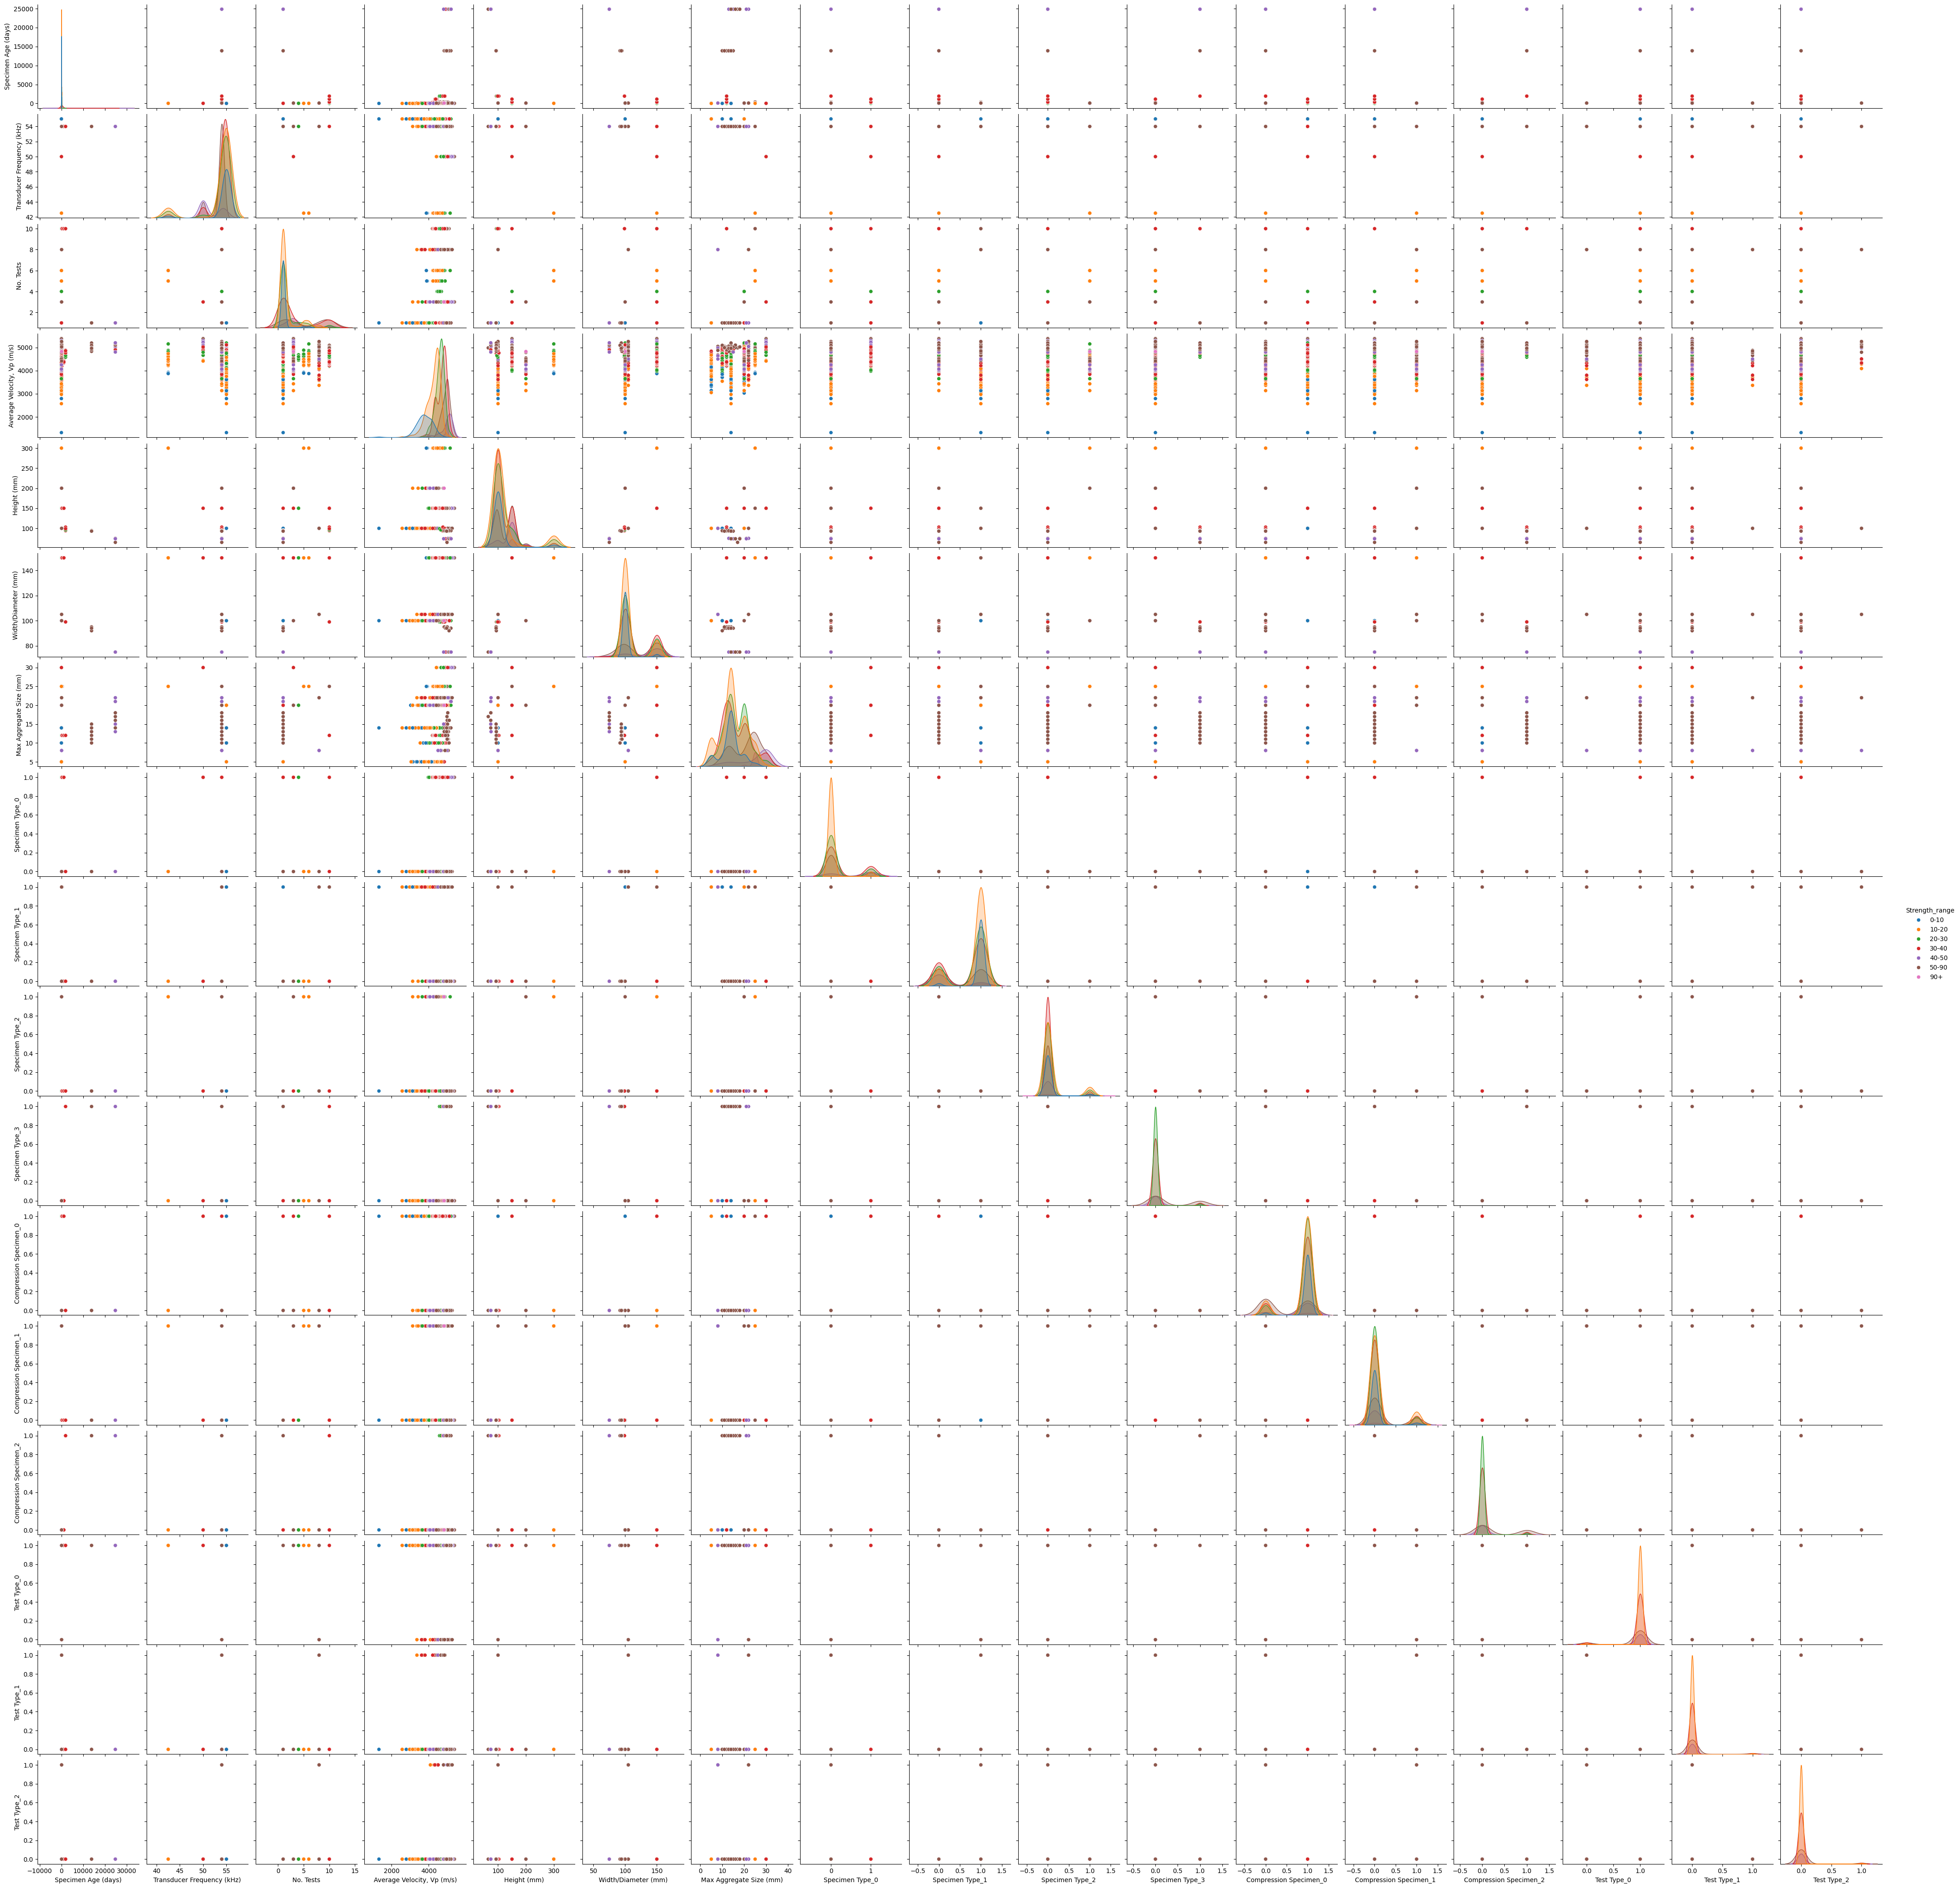

In [55]:
sns.pairplot(df_processed, hue='Strength_range')
plt.show()

In [56]:
#df = df.dropna(subset=['Target'])
df_train, df_test = train_test_split(df_processed, test_size=0.3, random_state=42)

In [57]:
df_train

,Specimen Age (days),Transducer Frequency (kHz),No. Tests,"Average Velocity, Vp (m/s)",Height (mm),Width/Diameter (mm),Max Aggregate Size (mm),Strength_range,Specimen Type_0,Specimen Type_1,Specimen Type_2,Specimen Type_3,Compression Specimen_0,Compression Specimen_1,Compression Specimen_2,Test Type_0,Test Type_1,Test Type_2
543,28.0,55.0,1.0,4640,100.0,100.0,10.0,10-20,False,True,False,False,True,False,False,True,False,False
442,60.0,55.0,1.0,4520,100.0,100.0,14.0,10-20,False,True,False,False,True,False,False,True,False,False
915,280.0,54.0,10.0,4292,150.0,150.0,12.0,30-40,True,False,False,False,True,False,False,True,False,False
398,21.0,55.0,1.0,4670,100.0,100.0,14.0,20-30,False,True,False,False,True,False,False,True,False,False
960,91.0,54.0,3.0,4412,200.0,100.0,20.0,50-90,False,False,True,False,False,True,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,28.0,54.0,10.0,4590,150.0,150.0,25.0,50-90,False,True,False,False,True,False,False,True,False,False
270,21.0,55.0,1.0,4870,100.0,100.0,14.0,20-30,False,True,False,False,True,False,False,True,False,False
860,90.0,54.0,8.0,4759,100.0,105.0,22.0,50-90,False,True,False,False,False,True,False,False,True,False
435,28.0,55.0,1.0,4360,100.0,100.0,14.0,10-20,False,True,False,False,True,False,False,True,False,False


In [60]:
target = 'Strength_range'
attributes = list(df_processed.columns[(df_processed.columns != target)])

In [61]:
#Padronizando dados:

min_max_scaler = preprocessing.MinMaxScaler()
min_max_scaler.fit(df_train[attributes])

# transformar os dados para a nova escala (treino e teste)
df_train_norm = min_max_scaler.transform(df_train[attributes])
df_test_norm = min_max_scaler.transform(df_test[attributes])

In [62]:
models_k = {}
 
for k in [1, 3, 5]:
    # preparando o knn com voto ponderado
    knn_norm = KNeighborsClassifier(n_neighbors=k,weights='distance',metric='euclidean')

    # conjunto de treino
    X_train = df_train_norm
    y_train = df_train[[target]]
    knn_norm.fit(X_train, y_train)

    # conjunto de teste
    X_test = df_test_norm
    y_test = df_test[[target]]

    y_pred = knn_norm.predict(X_test)

    # comparando desempenho

    acc = knn_norm.score(X_test, y_test)
    models_k[k] = {"modelo": knn_norm, "acuracia": acc}
    print(f"\n── k = {k}  |  Acurácia: {acc:.2%} ──")
    print(classification_report(y_test, y_pred))

C:\Users\juliafmoura\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)



── k = 1  |  Acurácia: 57.28% ──
              precision    recall  f1-score   support

        0-10       0.60      0.78      0.68        27
       10-20       0.73      0.48      0.58        94
       20-30       0.40      0.52      0.45        65
       30-40       0.56      0.59      0.57        66
       40-50       0.67      0.45      0.54        22
       50-90       0.68      0.88      0.76        24
         90+       1.00      0.75      0.86         4

    accuracy                           0.57       302
   macro avg       0.66      0.64      0.63       302
weighted avg       0.60      0.57      0.57       302


── k = 3  |  Acurácia: 57.62% ──
              precision    recall  f1-score   support

        0-10       0.57      0.78      0.66        27
       10-20       0.70      0.53      0.61        94
       20-30       0.44      0.51      0.47        65
       30-40       0.55      0.59      0.57        66
       40-50       0.64      0.41      0.50        22
       50-

C:\Users\juliafmoura\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
C:\Users\juliafmoura\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


In [64]:
# Classificador nulo que apenas chuta uma resposta considerando a distribuições das classes
dummy_clf = DummyClassifier(strategy='stratified')
dummy_clf.fit(X_train,y_train)
print(classification_report(y_test, dummy_clf.predict(X_test)))

              precision    recall  f1-score   support

        0-10       0.04      0.04      0.04        27
       10-20       0.28      0.22      0.25        94
       20-30       0.25      0.31      0.28        65
       30-40       0.29      0.27      0.28        66
       40-50       0.00      0.00      0.00        22
       50-90       0.09      0.17      0.11        24
         90+       0.00      0.00      0.00         4

    accuracy                           0.21       302
   macro avg       0.14      0.14      0.14       302
weighted avg       0.22      0.21      0.21       302



In [66]:
# Validação cruzada estratificada
X = df_processed.drop(columns=['Strength_range']).values
y = df_processed['Strength_range'].values
scaler = StandardScaler()
skf = StratifiedKFold(n_splits=10, random_state=42, shuffle=True)

print(X)
for k in [1, 3, 5]:
    fold_accuracies = []
    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):

        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        X_train_sc = scaler.fit_transform(X_train)
        X_test_sc  = scaler.transform(X_test)

        clf = KNeighborsClassifier(n_neighbors=k, weights='distance', metric='euclidean')
        clf.fit(X_train_sc, y_train)

        predictions   = clf.predict(X_test_sc)
        accuracy      = accuracy_score(y_test, predictions)
        fold_accuracies.append(accuracy)

        print(f"  Fold {fold:02d}" f"| Acurácia: {accuracy:.4f}")

    print(f"  Acurácia média (k={k}): {np.mean(fold_accuracies):.4f} \n")

[[1.0 50.0 3.0 ... True False False]
 [2.0 50.0 3.0 ... True False False]
 [7.0 50.0 3.0 ... True False False]
 ...
 [13880.0 54.0 1.0 ... True False False]
 [13880.0 54.0 1.0 ... True False False]
 [13880.0 54.0 1.0 ... True False False]]
  Fold 01| Acurácia: 0.6238
  Fold 02| Acurácia: 0.5248
  Fold 03| Acurácia: 0.5050
  Fold 04| Acurácia: 0.5446
  Fold 05| Acurácia: 0.5545
  Fold 06| Acurácia: 0.5347
  Fold 07| Acurácia: 0.5700
  Fold 08| Acurácia: 0.6100
  Fold 09| Acurácia: 0.5700
  Fold 10| Acurácia: 0.5200
  Acurácia média (k=1): 0.5557 

  Fold 01| Acurácia: 0.6040
  Fold 02| Acurácia: 0.5743
  Fold 03| Acurácia: 0.5248
  Fold 04| Acurácia: 0.5545
  Fold 05| Acurácia: 0.6337
  Fold 06| Acurácia: 0.5545
  Fold 07| Acurácia: 0.5800
  Fold 08| Acurácia: 0.5700
  Fold 09| Acurácia: 0.5700
  Fold 10| Acurácia: 0.5600
  Acurácia média (k=3): 0.5726 

  Fold 01| Acurácia: 0.6238
  Fold 02| Acurácia: 0.6040
  Fold 03| Acurácia: 0.5347
  Fold 04| Acurácia: 0.5347
  Fold 05| Acurácia: 0